# Klausuraufgabe: Autonomes Notbremssystem (AEB)
**Modul:** Machine Learning in den Ingenieurwissenschaften  
**Zeitvorgabe:** 30 Minuten

### Das Szenario
Ein Automobilhersteller testet ein neues sensorgestütztes Notbremssystem (Autonomous Emergency Braking – AEB). In Testfahrten fährt ein Fahrzeug mit einer bestimmten Initialgeschwindigkeit auf ein Hindernis zu. Das System leitet zu einem zufälligen Zeitpunkt eine Vollbremsung ein. 

Ihnen liegt der Datensatz `notbrems_daten.csv` vor mit den Features:
*   `Geschwindigkeit_kmh`: Geschwindigkeit $v$ im Moment des Bremsens.
*   `Abstand_m`: Abstand $d$ zum Hindernis im Moment des Bremsens.
*   `Kollision`: Binäres Label ($0 = \text{Sicher}$ zum Stehen gekommen, $1 = \text{Kollision}$).

Da Unfälle im Realbetrieb seltener sind als sichere Bremsungen, ist der Datensatz **unbalanciert** (Imbalanced Data). Für das AEB-System ist es jedoch fatal, eine Kollision nicht vorherzusagen (*False Negative*).

---

### WICHTIGER HINWEIS ZUR BEWERTUNG
Alle mathematischen Operationen, Transformationen, die Aktivierungsfunktion sowie der Gradientenschritt **sollen manuell mittels NumPy-Matrixoperationen (from Scratch) implementiert werden**. Die Nutzung von High-Level-Trainingsfunktionen (wie `sklearn.linear_model`) ist für den Hauptteil der Aufgabe untersagt.

**Der Sicherheitsgurt:** Sollte Ihre manuelle Implementierung fehlschlagen oder Fehlermeldungen erzeugen, dürfen Sie Scikit-Learn als Backup nutzen, um die nachfolgenden Evaluationen und Textfragen zu bearbeiten. Sie erhalten dann Teilabzug auf den Programmiercode, können aber die Punkte für die Datenanalyse und Interpretation komplett retten.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

# 1. Daten einlesen
df = pd.read_csv('notbrems_daten.csv')

# Features und Label trennen
X_raw = df[['Geschwindigkeit_kmh', 'Abstand_m']].values
y = df['Kollision'].values

# Aufgabe: Aufteilung in Train- und Testdaten (80/20) mit random_state=42
X_train_raw, X_test_raw, y_train, y_test =None, None, None, None  # TODO: Implementieren Sie die Aufteilung in Trainings- und Testdaten


print(f"Trainingsdaten erfolgreich geladen! Features: {X_train_raw.shape}, Labels: {y_train.shape}")

Trainingsdaten erfolgreich geladen! Features: (960, 2), Labels: (960,)


## 1. Explorative Datenanalyse & Feature-Visualisierung

Bevor wir Modelle trainieren, betrachten wir die geometrische Verteilung unserer Datenpunkte im Feature-Raum. Wir plotten die Daten in zwei verschiedenen Darstellungen nebeneinander:
1. **Links:** Der originale Zustand (Abstand über der Geschwindigkeit $v$).
2. **Rechts:** Der physikalisch transformierte Zustand (Abstand über der quadratischen Geschwindigkeit $v^2$).

Beobachten Sie dabei genau, was mit der Trenngrenze zwischen "Sicher" und "Kollision" passiert.

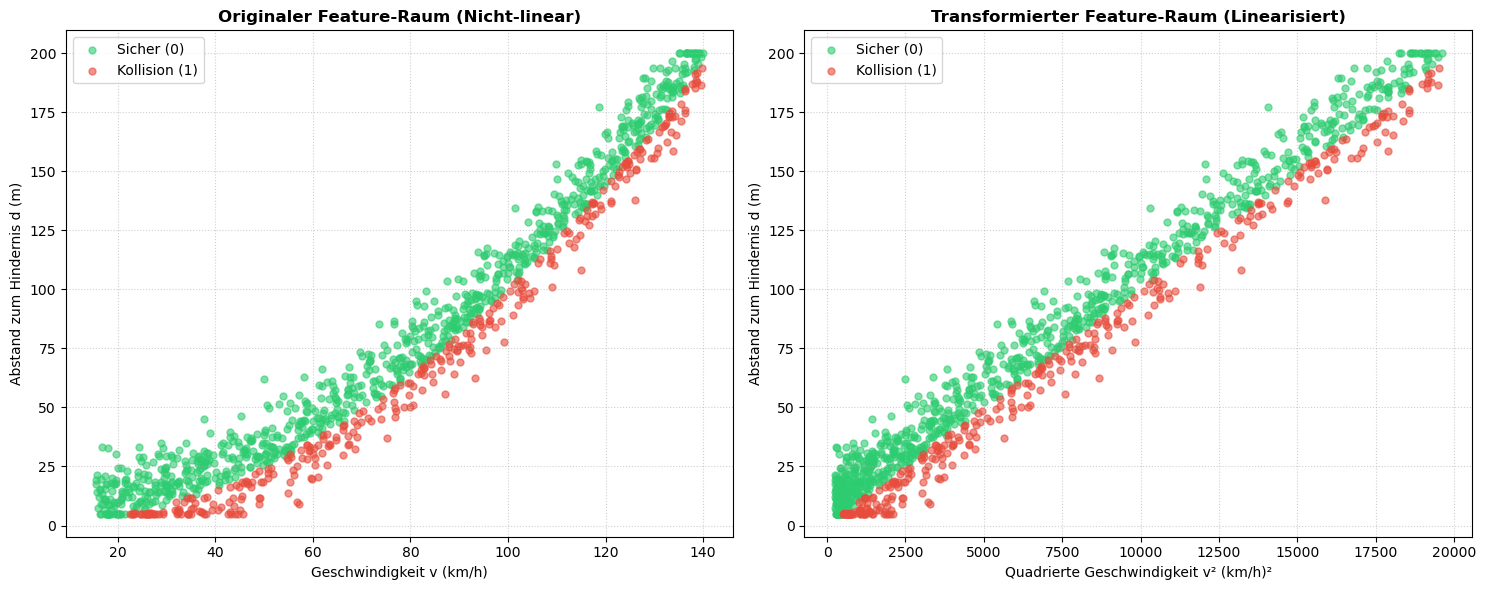

In [20]:
import matplotlib.pyplot as plt

# Extraktion der einzelnen physikalischen Größen für den Plot
geschwindigkeit = X_raw[:, 0]
abstand = X_raw[:, 1]
geschwindigkeit_quadriert = geschwindigkeit ** 2

# Subplots initialisieren (1 Zeile, 2 Spalten)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Masken für die beiden Klassen erstellen
mask_sicher = (y == 0)
mask_kollision = (y == 1)

# --- LINKER PLOT: Originale Features (Linear) ---
ax_left = axes[0]
ax_left.scatter(geschwindigkeit[mask_sicher], abstand[mask_sicher], 
                color='#2ecc71', alpha=0.6, label='Sicher (0)', s=25)
ax_left.scatter(geschwindigkeit[mask_kollision], abstand[mask_kollision], 
                color='#e74c3c', alpha=0.6, label='Kollision (1)', s=25)

ax_left.set_title('Originaler Feature-Raum (Nicht-linear)', fontsize=12, fontweight='bold')
ax_left.set_xlabel('Geschwindigkeit v (km/h)')
ax_left.set_ylabel('Abstand zum Hindernis d (m)')
ax_left.grid(True, linestyle=':', alpha=0.6)
ax_left.legend()

# --- RECHTER PLOT: Physikalisches Feature (Quadratisch) ---
ax_right = axes[1]
ax_right.scatter(geschwindigkeit_quadriert[mask_sicher], abstand[mask_sicher], 
                 color='#2ecc71', alpha=0.6, label='Sicher (0)', s=25)
ax_right.scatter(geschwindigkeit_quadriert[mask_kollision], abstand[mask_kollision], 
                 color='#e74c3c', alpha=0.6, label='Kollision (1)', s=25)

ax_right.set_title('Transformierter Feature-Raum (Linearisiert)', fontsize=12, fontweight='bold')
ax_right.set_xlabel('Quadrierte Geschwindigkeit v² (km/h)²')
ax_right.set_ylabel('Abstand zum Hindernis d (m)')
ax_right.grid(True, linestyle=':', alpha=0.6)
ax_right.legend()

plt.tight_layout()
plt.show()

## 2. Feature Engineering

Aus der Fahrzeugphysik wissen wir, dass der Bremsweg nicht linear, sondern **quadratisch** mit der Geschwindigkeit ansteigt ($s = k \cdot v^2$, wobei $k$ eine Proportionalitätskonstante ist).

Untersuchen Sie, wie sich lineare vs. quadratische Features auf die Performance auswirken.

**Ihre Aufgabe:** Implementieren Sie die Funktion `prepare_features`. Diese soll je nach gewähltem Modelltyp entweder die linearen Originalfeatures zurückgeben oder das physikalisch motivierte quadratische Feature erzeugen. Fügen Sie für den Bias-Term ($b$) eine Spalte aus Einsen an die Matrix an!

In [16]:
def prepare_features(X_matrix, model_type='linear'):
    """
    X_matrix: Matrix der Form (N, 2) mit [Geschwindigkeit, Abstand]
    model_type: 'linear' oder 'quadratic'
    Rückgabe: Transformierte Matrix inklusive Spalte aus Einsen für den Bias.
    """
    N = X_matrix.shape[0]
    v = X_matrix[:, 0]
    d = X_matrix[:, 1]
    
    X_transformed = None
    
    if model_type == 'linear':
        # Erstellen Sie eine Matrix aus [v, d, 1]
        # #####################################################################
        # Your Code
        pass
        # #####################################################################
        
    elif model_type == 'quadratic':
        # Erstellen Sie eine Matrix aus [v^2, d, 1] unter Berücksichtigung der Physik
        # #####################################################################
        # Your Code
        pass
        # #####################################################################
        
    return X_transformed

**Zur Kontrolle der Feature-Transformation mit Sklearn:**

Sie können prüfen, ob Ihre manuell erstellte Matrix die korrekte Form und Werte besitzt, indem Sie das Ergebnis mit der Klasse `PolynomialFeatures` abgleichen.
Für den quadratischen Fall ($v^2, d, 1$) entspricht das folgendem Schema:

In [17]:
from sklearn.preprocessing import PolynomialFeatures
# Das erzeugt [1, v, d, v^2, v*d, d^2]. Sie benötigen davon nur die Spalten für v^2, d und 1.
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X_train_raw)

## 3. Manuelle Implementierung: Gewichtete Logistische Regression

Um das Problem der unbalancierten Daten zu lösen, modifizieren wir die Kostenfunktion (Log-Loss). Wir führen ein Gewicht $w_{\text{pos}}$ für die positive Klasse (Kollision) ein. 

Der modifizierte Gradient der Kostenfunktion nach den Gewichten $w$ (inklusive Bias) lautet mathematisch:
$$\nabla L = \frac{1}{N} X^T \cdot \Big( W \odot (\sigma(Xw) - y) \Big)$$
Wobei $W$ ein Vektor ist, der für jeden Datenpunkt das entsprechende Klassengewicht enthält: $W_i = w_{\text{pos}}$ falls $y_i = 1$, ansonsten $1.0$. Das Symbol $\odot$ steht für die elementweise Multiplikation.

**Ihre Aufgabe:** Implementieren Sie die Sigmoid-Aktivierungsfunktion und den Gradientenschritt *from Scratch* unter Verwendung von NumPy-Matrixoperationen.

In [18]:
def sigmoid(z):
    # Implementieren Sie die mathematische Sigmoid-Funktion
    # #####################################################################
    # Your Code
    return None
    # #####################################################################

def train_weighted_log_reg(X, y, w_pos=1.0, lr=0.001, epochs=5000):
    """
    X: Feature-Matrix (N, M) inkl. Einsen-Spalte
    y: Label-Vektor (N,)
    w_pos: Gewicht für die positive Klasse (Kollision)
    """
    N, M = X.shape
    w = np.zeros(M) # Gewichte mit Nullen initialisieren
    
    # Vorbereitung des Gewichtsvektors W für die Stichproben
    W = np.where(y == 1, w_pos, 1.0)
    
    for epoch in range(epochs):
        # 1. Forward Pass: Berechnen Sie den linearen Score z und die Aktivierung h
        # #####################################################################
        # Your Code
        h = None
        # #####################################################################
        
        # 2. Gradientenberechnung unter Verwendung von W, X, h und y
        # #####################################################################
        # Your Code
        gradient = None
        # #####################################################################
        
        # 3. Gewichtsupdate (Gradient Descent Schritt)
        # #####################################################################
        # Your Code
        pass
        # #####################################################################
        
    return w

**Zur Kontrolle des Trainingsschritts mit Sklearn:**
Falls Ihre manuelle Schleife nicht ordnungsgemäß funktioniert oder Sie Ihre gelernten Gewichte `w` verifizieren möchten, können Sie das mathematische Äquivalent in Sklearn wie folgt aufrufen:

```python
from sklearn.linear_model import LogisticRegression

# Für ungewichteten Loss (w_pos = 1.0):
# fit_intercept=False, da die Einsen-Spalte bereits manuell in X enthalten ist
model_sklearn = LogisticRegression(fit_intercept=False) 

# Für gewichteten Loss (w_pos = 10.0):
model_sklearn_weighted = LogisticRegression(class_weight={0: 1.0, 1: 10.0}, fit_intercept=False)

In [5]:
from sklearn.linear_model import LogisticRegression
# Für ungewichteten Loss (w_pos = 1.0):
model_sklearn = LogisticRegression(fit_intercept=False) # Da die 1er-Spalte schon in X ist

# Für gewichteten Loss (w_pos = 10.0):
model_sklearn_weighted = LogisticRegression(class_weight={0: 1.0, 1: 10.0}, fit_intercept=False)

## 4. Das Experiment: Training & Evaluation der 3 Modelle

Wir vergleichen nun systematisch drei Konfigurationen, um den Effekt von Physik (Feature Selection) und Kosten-Gewichtung (Imbalanced Data) zu verstehen:
*   **Modell 1:** Lineare Features, Standard-Gewichtung ($w_{\text{pos}} = 1.0$)
*   **Modell 2:** Quadratische Features, Standard-Gewichtung ($w_{\text{pos}} = 1.0$)
*   **Modell 3:** Quadratische Features, Hohe Gewichtung ($w_{\text{pos}} = 10.0$)

Die Trainingsschleife greift auf Ihre oben definierten Funktionen zurück.

In [7]:
# Definition der Experimente
experiments = {
    "Modell 1 (Lin / Normal)":  {"type": "linear",    "w_pos": 1.0},
    "Modell 2 (Quad / Normal)": {"type": "quadratic", "w_pos": 1.0},
    "Modell 3 (Quad / Weighted)":{"type": "quadratic", "w_pos": 10.0}
}

# Schleife über alle 3 Modelle zur automatischen Auswertung
for name, cfg in experiments.items():
    # Daten transformieren
    X_train = prepare_features(X_train_raw, model_type=cfg["type"])
    X_test = prepare_features(X_test_raw, model_type=cfg["type"])
    
    # Sicherstellen, dass die Daten nicht None sind (falls oben noch nichts implementiert wurde)
    if X_train is None or X_test is None:
        print(f"Skipping {name}: Features wurden noch nicht implementiert.")
        continue
        
    # Modell trainieren (Lernrate und Epochen sind optimiert vorgegeben)
    w_learned = train_weighted_log_reg(X_train, y_train, w_pos=cfg["w_pos"], lr=0.0001, epochs=15000)
    
    # Vorhersage auf Testdaten berechnen (Threshold = 0.5)
    z_test = np.dot(X_test, w_learned)
    probabilities = sigmoid(z_test)
    
    if probabilities is None:
        print(f"Skipping {name}: Sigmoid-Funktion liefert keine Rückgabe.")
        continue
        
    y_pred = (probabilities >= 0.5).astype(int)
    
    # Evaluation mittels sklearn Metriken
    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n=== {name} ===")
    print(f"Gelerntes Gewichtskonstrukt (w): {np.round(w_learned, 4)}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"F1-Score: {f1:.4f}")

Skipping Modell 1 (Lin / Normal): Features wurden noch nicht implementiert.
Skipping Modell 2 (Quad / Normal): Features wurden noch nicht implementiert.
Skipping Modell 3 (Quad / Weighted): Features wurden noch nicht implementiert.


**Zur Kontrolle der finalen Performance-Metriken:**
Falls Ihr eigener Trainingsloop fehlerhaft war und Sie für die folgenden Textfragen die korrekten Metriken der drei Modelle benötigen, können Sie diese in einer neuen Testzelle schnell mit diesem Sklearn-Block erzeugen und abgleichen:

```python
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix

# Beispiel-Kontrolle für Modell 3 (Quadratisch / Gewichtet):
# Wir schneiden die letzte Spalte ab ([:, :2]), da Sklearn den Intercept standardmäßig selbst berechnet
X_tr_q = prepare_features(X_train_raw, model_type='quadratic')[:, :2] 
X_te_q = prepare_features(X_test_raw, model_type='quadratic')[:, :2]

clf = LogisticRegression(class_weight={0: 1.0, 1: 10.0})
clf.fit(X_tr_q, y_train)
y_sklearn_pred = clf.predict(X_te_q)

print("Sklearn Modell 3 F1-Score:", f1_score(y_test, y_sklearn_pred))
print("Sklearn Modell 3 Confusion Matrix:\n", confusion_matrix(y_test, y_sklearn_pred))

In [8]:
from sklearn.linear_model import LogisticRegression

# Beispiel-Kontrolle für Modell 3:
X_tr_q = prepare_features(X_train_raw, model_type='quadratic')[:, :2] # Sklearn fügt Intercept selbst hinzu
X_te_q = prepare_features(X_test_raw, model_type='quadratic')[:, :2]

clf = LogisticRegression(class_weight={0: 1.0, 1: 10.0})
clf.fit(X_tr_q, y_train)
y_sklearn_pred = clf.predict(X_te_q)
print("Sklearn F1-Score:", f1_score(y_test, y_sklearn_pred))

TypeError: 'NoneType' object is not subscriptable

## 5. Interpretation & Kritisches Denken (Theorie)

Bitte beantworten Sie die folgenden Fragen direkt in dieser Markdown-Zelle:

1.  **Die Rolle der Physik:** Vergleichen Sie die Ergebnisse von Modell 1 (linear) und Modell 2 (quadratisch). Welchen drastischen Unterschied sehen Sie beim F1-Score und warum ist dieser Sprung durch die Berücksichtigung der physikalischen Bremsformel ($s= k \cdot v^2 $) im Feature Engineering zu erklären?


In [ ]:
# Ihre Antwort:
    


2.  **Umgang mit unbalancierten Daten:** Betrachten Sie die Confusion Matrix von Modell 2 im Vergleich zu Modell 3. 

Wie viele *False Negatives* (Unfälle, die fälschlicherweise als "Sicher" klassifiziert wurden) gab es jeweils? 

Warum schützt uns Modell 3 besser vor katastrophalen Fehlentscheidungen im realen Straßenverkehr und welchen Preis zahlen wir dafür bei den *False Alerts* (Fehlalarmen)?

In [9]:
# Ihre Antwort: